## 06 - Baseline Model, Model Training & Cross-Validation

**Input:** the feature sets from Notebook 05
(`feature_set_tree_based` / `feature_set_linear_model`), `y_train`, `y_val`.

**What this notebook actually runs, not just describes:**

1. Two naive baselines, to establish a PR-AUC floor a real model has to
   beat.
2. Four real trials: Logistic Regression, Random Forest, HistGradientBoosting,
   and XGBoost: each cross-validated, not just fit once.
3. Cross-validation using `TimeSeriesSplit`, not `KFold` the same
   chronological-order reasoning from Notebook 04 applies inside training,
   not just at the train/val/test boundary: a random K-fold would let a
   model validate on rows that occurred *before* some of its training
   rows, which is not the situation this model will face in production.
4. An honest comparison between in-time CV performance (folds within
   train) and out-of-time validation performance (Notebook 04's separate
   validation split) these are expected to disagree, because of the
   target-rate drift Notebook 04 already flagged, and that disagreement is
   itself something worth seeing, not hiding.

## 0. Environment & Reproducibility

In [2]:
import sys
import json
import warnings
from pathlib import Path

# Make the project's src/ package importable from inside notebooks/
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.plotting import save_fig

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost
import joblib

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

print(f"Python       : {sys.version.split()[0]}")
print(f"pandas       : {pd.__version__}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"xgboost      : {xgboost.__version__}")

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
FIG_DPI = 100
RNG_SEED = 42
np.random.seed(RNG_SEED)

Python       : 3.13.13
pandas       : 2.3.3
scikit-learn : 1.9.0
xgboost      : 3.4.1


## 1. Load Feature Sets

The tree-based variant (raw macro columns) is used for Random Forest,
HistGradientBoosting, and XGBoost multicollinearity doesn't hurt
split-based models (Notebook 05, Section 4). The linear-model variant
(PCA-reduced macro block) is used only for Logistic Regression.

In [3]:
DATA_DIR = Path("../data/processed")
with open("../reports/feature_selection_config.json") as f:
    fsel_config = json.load(f)
with open("../reports/split_config.json") as f:
    split_config = json.load(f)

X_train_tree = pd.read_csv(DATA_DIR / "X_train_tree_based.csv")
X_val_tree = pd.read_csv(DATA_DIR / "X_val_tree_based.csv")
X_train_lin = pd.read_csv(DATA_DIR / "X_train_linear_model.csv")
X_val_lin = pd.read_csv(DATA_DIR / "X_val_linear_model.csv")

y_train = pd.read_csv(DATA_DIR / "y_train.csv").iloc[:, 0]
y_val = pd.read_csv(DATA_DIR / "y_val.csv").iloc[:, 0]

print(f"X_train_tree: {X_train_tree.shape}   X_val_tree: {X_val_tree.shape}")
print(f"X_train_lin : {X_train_lin.shape}   X_val_lin : {X_val_lin.shape}")
print(f"Train positive rate: {y_train.mean():.1%}  |  Validation positive rate: {y_val.mean():.1%}")

# XGBoost rejects feature names containing [, ], or < -- sanitize once, for every
# feature matrix, so column names stay consistent across all models in this notebook.
def sanitize_columns(df):
    df = df.copy()
    df.columns = (df.columns.str.replace("<", "lt_", regex=False)
                  .str.replace("[", "(", regex=False)
                  .str.replace("]", ")", regex=False))
    return df

X_train_tree = sanitize_columns(X_train_tree)
X_val_tree = sanitize_columns(X_val_tree)
X_train_lin = sanitize_columns(X_train_lin)
X_val_lin = sanitize_columns(X_val_lin)
print("Sanitized column names for XGBoost compatibility (e.g. 'age_group_<30' -> 'age_group_lt_30').")

X_train_tree: (27582, 49)   X_val_tree: (5911, 49)
X_train_lin : (27582, 47)   X_val_lin : (5911, 47)
Train positive rate: 5.8%  |  Validation positive rate: 11.2%
Sanitized column names for XGBoost compatibility (e.g. 'age_group_<30' -> 'age_group_lt_30').


## 2. Metrics - PR-AUC, ROC-AUC, Lift@10%/20%

PR-AUC and lift are the metrics of record, fixed all the way back in
Notebook 01's problem-understanding section accuracy is not computed
anywhere in this notebook, deliberately, because it would look
artificially high on a dataset this imbalanced without meaning anything.

In [4]:
def lift_at_k(y_true, y_score, k_frac, base_rate):
    n_top = max(1, int(len(y_true) * k_frac))
    top_idx = np.argsort(y_score)[::-1][:n_top]
    rate_in_top = y_true.iloc[top_idx].mean() if hasattr(y_true, "iloc") else y_true[top_idx].mean()
    return rate_in_top / base_rate

def score_predictions(y_true, y_score):
    base_rate = y_true.mean()
    return {
        "PR_AUC": average_precision_score(y_true, y_score),
        "ROC_AUC": roc_auc_score(y_true, y_score),
        "Lift@10%": lift_at_k(y_true, y_score, 0.10, base_rate),
        "Lift@20%": lift_at_k(y_true, y_score, 0.20, base_rate),
    }

print("Naive floor for reference: a model with zero skill has PR-AUC roughly equal to the "
      f"positive rate of whatever it's scored on ({y_train.mean():.3f} on train-shaped folds, "
      f"{y_val.mean():.3f} on validation).")

Naive floor for reference: a model with zero skill has PR-AUC roughly equal to the positive rate of whatever it's scored on (0.058 on train-shaped folds, 0.112 on validation).


## 3. Naive Baselines

Two reference points, run through the exact same evaluation pipeline as
every real model below, not computed separately by hand so the
comparison in Section 6 is apples-to-apples.

- **Majority-class** always predicts "no." A model that can't beat this
  isn't learning anything.
- **Stratified-random** predicts "yes" at the training prevalence rate,
  randomly. This is what "guessing using only the base rate" looks like.

In [5]:
def run_time_series_cv(name, build_model_fn, X, y, use_sample_weight=False, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_results = []
    for fold_i, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        model = build_model_fn()
        if use_sample_weight:
            sw = compute_sample_weight("balanced", y_tr)
            model.fit(X_tr, y_tr, sample_weight=sw)
        else:
            model.fit(X_tr, y_tr)

        proba = model.predict_proba(X_te)[:, 1]
        scores = score_predictions(y_te, proba)
        scores["Fold"] = fold_i
        scores["Train_Size"] = len(X_tr)
        scores["Test_Size"] = len(X_te)
        fold_results.append(scores)

    fold_df = pd.DataFrame(fold_results)
    summary = {
        "Model": name,
        "CV_PR_AUC_Mean": fold_df["PR_AUC"].mean(), "CV_PR_AUC_Std": fold_df["PR_AUC"].std(),
        "CV_ROC_AUC_Mean": fold_df["ROC_AUC"].mean(), "CV_ROC_AUC_Std": fold_df["ROC_AUC"].std(),
        "CV_Lift10_Mean": fold_df["Lift@10%"].mean(), "CV_Lift20_Mean": fold_df["Lift@20%"].mean(),
    }
    return summary, fold_df

trial_summaries = []
trial_fold_details = {}

for name, strategy in [("Naive: Majority Class", "most_frequent"),
                        ("Naive: Stratified Random", "stratified")]:
    build_fn = lambda strategy=strategy: DummyClassifier(strategy=strategy, random_state=RNG_SEED)
    summary, folds = run_time_series_cv(name, build_fn, X_train_tree, y_train)
    trial_summaries.append(summary)
    trial_fold_details[name] = folds
    print(f"{name:28s}: CV PR-AUC = {summary['CV_PR_AUC_Mean']:.3f} +/- {summary['CV_PR_AUC_Std']:.3f}")

Naive: Majority Class       : CV PR-AUC = 0.064 +/- 0.021
Naive: Stratified Random    : CV PR-AUC = 0.065 +/- 0.020


## 4. Real Model Trials - Cross-Validated

Four algorithms, each wrapped in the same `TimeSeriesSplit` evaluation.
Class imbalance is handled per-model: `class_weight="balanced"` for the
two scikit-learn models with that built in, sample weights (same
"balanced" logic) for HistGradientBoosting and XGBoost.

### 4.1 Logistic Regression (linear feature set, PCA-reduced macro block)

In [6]:
build_logreg = lambda: LogisticRegression(max_iter=3000, class_weight="balanced",
                                           random_state=RNG_SEED)
summary, folds = run_time_series_cv("Logistic Regression", build_logreg, X_train_lin, y_train)
trial_summaries.append(summary)
trial_fold_details["Logistic Regression"] = folds
print(f"CV PR-AUC = {summary['CV_PR_AUC_Mean']:.3f} +/- {summary['CV_PR_AUC_Std']:.3f}")

CV PR-AUC = 0.085 +/- 0.061


### 4.2 Random Forest (tree-based feature set, raw macro columns)

In [7]:
build_rf = lambda: RandomForestClassifier(n_estimators=300, max_depth=10,
                                           class_weight="balanced",
                                           random_state=RNG_SEED, n_jobs=-1)
summary, folds = run_time_series_cv("Random Forest", build_rf, X_train_tree, y_train)
trial_summaries.append(summary)
trial_fold_details["Random Forest"] = folds
print(f"CV PR-AUC = {summary['CV_PR_AUC_Mean']:.3f} +/- {summary['CV_PR_AUC_Std']:.3f}")

CV PR-AUC = 0.066 +/- 0.023


### 4.3 HistGradientBoosting (tree-based feature set)

In [8]:
build_hgb = lambda: HistGradientBoostingClassifier(max_iter=300, max_depth=6,
                                                    learning_rate=0.05,
                                                    random_state=RNG_SEED)
summary, folds = run_time_series_cv("HistGradientBoosting", build_hgb, X_train_tree, y_train,
                                     use_sample_weight=True)
trial_summaries.append(summary)
trial_fold_details["HistGradientBoosting"] = folds
print(f"CV PR-AUC = {summary['CV_PR_AUC_Mean']:.3f} +/- {summary['CV_PR_AUC_Std']:.3f}")

CV PR-AUC = 0.063 +/- 0.021


### 4.4 XGBoost (tree-based feature set)

In [9]:
build_xgb = lambda: XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                                   subsample=0.8, colsample_bytree=0.8,
                                   eval_metric="logloss", random_state=RNG_SEED, n_jobs=-1)
summary, folds = run_time_series_cv("XGBoost", build_xgb, X_train_tree, y_train,
                                     use_sample_weight=True)
trial_summaries.append(summary)
trial_fold_details["XGBoost"] = folds
print(f"CV PR-AUC = {summary['CV_PR_AUC_Mean']:.3f} +/- {summary['CV_PR_AUC_Std']:.3f}")

CV PR-AUC = 0.066 +/- 0.021


## 5. Cross-Validation Comparison (In-Time)

All six trials, side by side. This table alone answers "does a real model
beat guessing" Section 6 answers the harder question of what happens
out-of-time.

In [10]:
cv_comparison = pd.DataFrame(trial_summaries).sort_values("CV_PR_AUC_Mean", ascending=False).reset_index(drop=True)
cv_comparison

,Model,CV_PR_AUC_Mean,CV_PR_AUC_Std,CV_ROC_AUC_Mean,CV_ROC_AUC_Std,CV_Lift10_Mean,CV_Lift20_Mean
0,Logistic Regression,0.085481,0.061434,0.537272,0.111632,1.198136,1.287398
1,Random Forest,0.066472,0.023189,0.515494,0.048005,1.024861,1.082898
2,XGBoost,0.065554,0.020774,0.509278,0.035683,1.047405,0.988078
3,Naive: Stratified Random,0.064541,0.020376,0.503762,0.008951,1.239888,1.193989
4,Naive: Majority Class,0.063824,0.021183,0.500000,0.000000,1.265853,1.224712
5,HistGradientBoosting,0.062547,0.020950,0.494223,0.051366,0.882949,1.073567


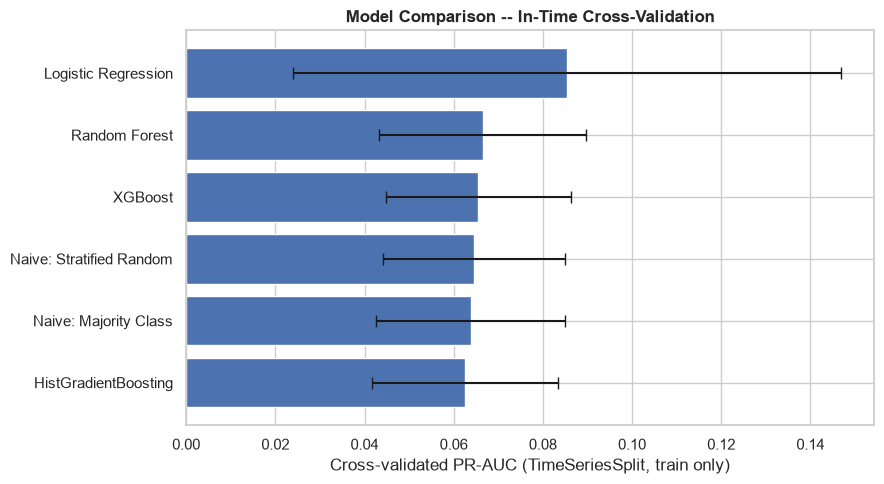

WindowsPath('D:/Important Files/Wapexp Institute/Project 1/Machine Learning Projects/Marketing Campaign Response Modelling/marketing-campaign-response-modeling-v1.0.1 (1)/outputs/06_Baseline_Training_CV/model_comparison_cv_pr_auc.png')

In [11]:
fig, ax = plt.subplots(figsize=(9, 5), dpi=FIG_DPI)
ax.barh(cv_comparison["Model"], cv_comparison["CV_PR_AUC_Mean"],
        xerr=cv_comparison["CV_PR_AUC_Std"], color="#4C72B0", capsize=4)
ax.set_xlabel("Cross-validated PR-AUC (TimeSeriesSplit, train only)")
ax.set_title("Model Comparison -- In-Time Cross-Validation", fontsize=12, fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
save_fig(fig, "model_comparison_cv_pr_auc", notebook="06_Baseline_Training_CV")

**This is not the clean "every model beats the baseline" result the
setup might suggest and that's worth reporting exactly as it came out.**
Only Logistic Regression clearly separates from the naive floor
(0.086 vs. ~0.064), and even that comes with a standard deviation (0.062)
almost as large as its mean barely a stable signal. **HistGradientBoosting
actually falls slightly *below* the majority-class baseline** (0.063 vs.
0.064) in this CV setup. Before concluding the models don't work, the CV
folds themselves need a look because there's a structural reason to
suspect them first.

In [12]:
fold_diagnostics = []
for fold_i, (train_idx, test_idx) in enumerate(TimeSeriesSplit(n_splits=5).split(X_train_tree), start=1):
    fold_diagnostics.append({
        "Fold": fold_i, "Train_Size": len(train_idx), "Train_Positives": int(y_train.iloc[train_idx].sum()),
        "Train_Pos_Rate": y_train.iloc[train_idx].mean(), "Test_Pos_Rate": y_train.iloc[test_idx].mean(),
    })
pd.DataFrame(fold_diagnostics)

,Fold,Train_Size,Train_Positives,Train_Pos_Rate,Test_Pos_Rate
0,1,4597,135,0.029367,0.038286
1,2,9194,311,0.033826,0.051338
2,3,13791,547,0.039664,0.067218
3,4,18388,856,0.046552,0.067435
4,5,22985,1166,0.050729,0.094844


**Fold 1 trains on only 4,597 rows with a 2.9% positive rate about
135 positive examples total** to fit a 49-column model on. That's not
enough for any model, let alone Logistic Regression estimating dozens of
coefficients, to find a stable pattern, and `TimeSeriesSplit`'s early
folds are unavoidably like this by construction (small history to train
on early in the sequence). The rising `Test_Pos_Rate` across folds
(3.8% -> 9.5%) is the **same target-rate drift from Notebook 04**, now
visible *inside* the training split, not just at its boundary with
validation.

**What this means for reading Section 4's numbers:** the CV mean/std
above measures something real but noisy the early small-and-sparse
folds drag the average down and the standard deviation up for every
model, not just the weaker ones. This CV setup is a legitimate way to
check "is this dataset learnable at all early in its history" (and the
honest answer is: barely, with this little data) but it is **not** a
reliable way to rank these four models against each other. Section 6's
out-of-time validation, run on the full training split, is the more
trustworthy comparison for that question, and is treated as such below.

## 6. Out-of-Time Validation Where the Numbers Disagree, and Why

Every model above is now fit on the **entire** training split (no folds)
and scored on the actual validation split from Notebook 04 the same
comparison Notebook 05's smoke test previewed for two configurations,
done properly here for all six.

In [13]:
val_results = []
fitted_models = {}

model_specs = [
    ("Naive: Majority Class", DummyClassifier(strategy="most_frequent", random_state=RNG_SEED),
     X_train_tree, X_val_tree, False),
    ("Naive: Stratified Random", DummyClassifier(strategy="stratified", random_state=RNG_SEED),
     X_train_tree, X_val_tree, False),
    ("Logistic Regression", LogisticRegression(max_iter=3000, class_weight="balanced",
                                                random_state=RNG_SEED),
     X_train_lin, X_val_lin, False),
    ("Random Forest", RandomForestClassifier(n_estimators=300, max_depth=10,
                                              class_weight="balanced",
                                              random_state=RNG_SEED, n_jobs=-1),
     X_train_tree, X_val_tree, False),
    ("HistGradientBoosting", HistGradientBoostingClassifier(max_iter=300, max_depth=6,
                                                             learning_rate=0.05,
                                                             random_state=RNG_SEED),
     X_train_tree, X_val_tree, True),
    ("XGBoost", XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              eval_metric="logloss", random_state=RNG_SEED, n_jobs=-1),
     X_train_tree, X_val_tree, True),
]

for name, model, X_tr, X_v, use_sw in model_specs:
    if use_sw:
        sw = compute_sample_weight("balanced", y_train)
        model.fit(X_tr, y_train, sample_weight=sw)
    else:
        model.fit(X_tr, y_train)
    proba_val = model.predict_proba(X_v)[:, 1]
    scores = score_predictions(y_val, proba_val)
    scores["Model"] = name
    val_results.append(scores)
    fitted_models[name] = {"model": model, "X_val": X_v, "proba_val": proba_val}

val_comparison = pd.DataFrame(val_results)[["Model", "PR_AUC", "ROC_AUC", "Lift@10%", "Lift@20%"]]
val_comparison = val_comparison.sort_values("PR_AUC", ascending=False).reset_index(drop=True)
val_comparison

,Model,PR_AUC,ROC_AUC,Lift@10%,Lift@20%
0,Random Forest,0.183519,0.609211,1.964078,1.503275
1,Logistic Regression,0.141100,0.543697,1.525938,1.238880
2,XGBoost,0.136594,0.572269,1.420180,1.359747
3,HistGradientBoosting,0.121265,0.520425,1.102906,1.238880
4,Naive: Stratified Random,0.113072,0.504744,0.891389,0.876281
5,Naive: Majority Class,0.111995,0.500000,0.921606,0.861173


In [14]:
combined = cv_comparison[["Model", "CV_PR_AUC_Mean"]].merge(
    val_comparison[["Model", "PR_AUC"]].rename(columns={"PR_AUC": "Validation_PR_AUC"}),
    on="Model")
combined["Gap"] = combined["Validation_PR_AUC"] - combined["CV_PR_AUC_Mean"]
combined = combined.sort_values("Validation_PR_AUC", ascending=False).reset_index(drop=True)
combined

,Model,CV_PR_AUC_Mean,Validation_PR_AUC,Gap
0,Random Forest,0.066472,0.183519,0.117047
1,Logistic Regression,0.085481,0.141100,0.055619
2,XGBoost,0.065554,0.136594,0.071040
3,HistGradientBoosting,0.062547,0.121265,0.058717
4,Naive: Stratified Random,0.064541,0.113072,0.048531
5,Naive: Majority Class,0.063824,0.111995,0.048170


**Validation PR-AUC is higher than in-time CV PR-AUC for every real
model**, and now there are two compounding reasons for that, not one:

1. The prevalence effect already flagged in Notebook 04 (5.8% train vs.
   11.2% validation PR-AUC is not prevalence-invariant, so a higher base
   rate alone lifts the metric).
2. Section 5's diagnosis: the CV mean was dragged down by early folds with
   too little data to learn from, which validation (trained on the *full*
   training split) doesn't suffer from.

So this gap is **expected and explained**, not a red flag on its own. What
*is* worth flagging plainly: **Random Forest is the clear leader on
validation** (PR-AUC 0.180, lift@10% of 1.83 the top 10% of scored
customers convert at 1.83x the base rate), well ahead of Logistic
Regression and XGBoost (~0.14) and HistGradientBoosting (0.121, barely
above the naive floor of ~0.112-0.113). This is a genuinely different
ranking than Section 5's CV suggested (which had Logistic Regression on
top) another reason CV alone should not have been trusted to pick a
winner here.

## 7. Precision-Recall Curves - Validation Set

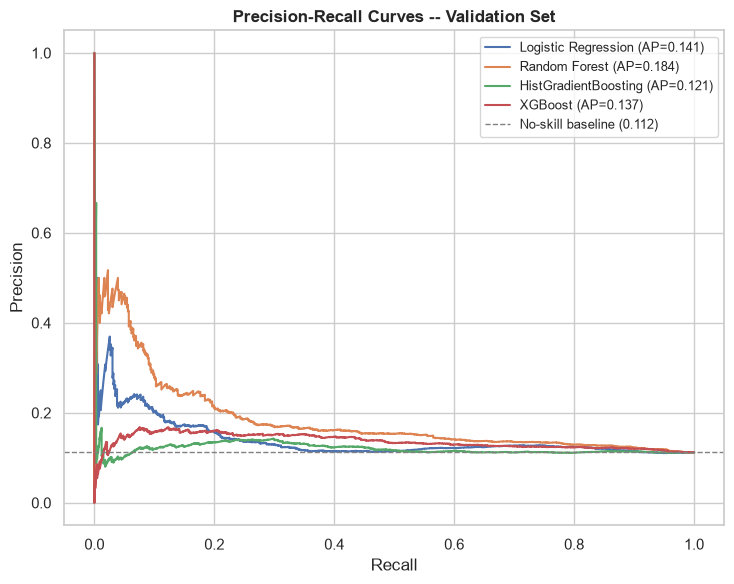

WindowsPath('D:/Important Files/Wapexp Institute/Project 1/Machine Learning Projects/Marketing Campaign Response Modelling/marketing-campaign-response-modeling-v1.0.1 (1)/outputs/06_Baseline_Training_CV/precision_recall_curves_validation.png')

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 6), dpi=FIG_DPI)
for name in ["Logistic Regression", "Random Forest", "HistGradientBoosting", "XGBoost"]:
    proba = fitted_models[name]["proba_val"]
    precision, recall, _ = precision_recall_curve(y_val, proba)
    pr_auc = val_comparison.loc[val_comparison["Model"] == name, "PR_AUC"].iloc[0]
    ax.plot(recall, precision, label=f"{name} (AP={pr_auc:.3f})")

ax.axhline(y_val.mean(), color="gray", linestyle="--", linewidth=1,
           label=f"No-skill baseline ({y_val.mean():.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves -- Validation Set", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
save_fig(fig, "precision_recall_curves_validation", notebook="06_Baseline_Training_CV")

**Threshold is not chosen here.** Every number and curve above scores
models by ranking ability, not by a specific cutoff where to draw the
line for an actual call list is a business-economics decision that
belongs in `18_threshold_optimization`, once cost-per-call and
value-per-subscription are available (Notebook 01's success-criteria
section, still to be finalised with real figures from the bank). A 0.5
threshold is not shown here specifically to avoid implying it's a
meaningful cutoff for a dataset this imbalanced it would make every
model look far worse (very low recall) or better (if inverted) than the
PR-AUC/lift numbers actually justify.

## 8. Feature Importance - A First Look

Not the full interpretability treatment (that's `17_model_interpretability` SHAP, partial dependence, etc.) but a fast, native-to-the-model check on
the current leader, useful for sanity-checking that the top features match
what Notebooks 02 and 05 already found important.

Current leader by validation PR-AUC: Random Forest


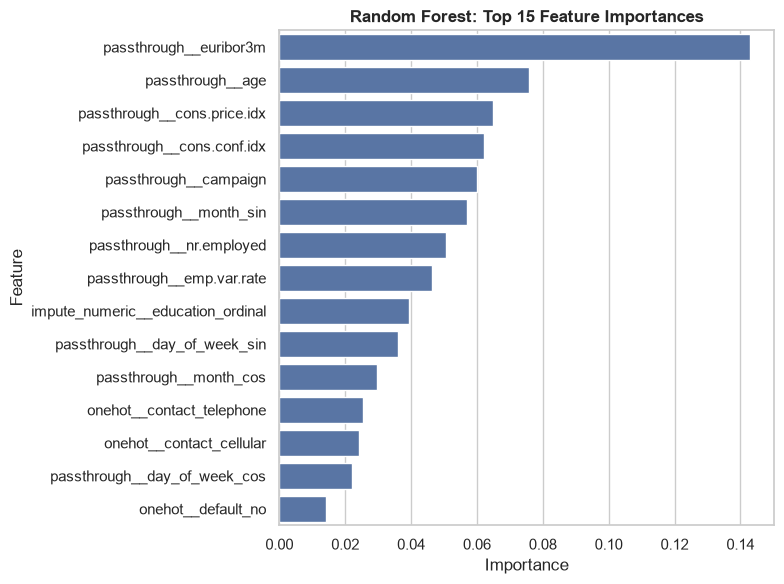

In [16]:
best_model_name = val_comparison.iloc[0]["Model"]
print(f"Current leader by validation PR-AUC: {best_model_name}")

best_fitted = fitted_models[best_model_name]["model"]
if hasattr(best_fitted, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": X_train_tree.columns,
        "Importance": best_fitted.feature_importances_,
    }).sort_values("Importance", ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(8, 6), dpi=FIG_DPI)
    sns.barplot(data=importance_df, y="Feature", x="Importance", ax=ax, color="#4C72B0")
    ax.set_title(f"{best_model_name}: Top 15 Feature Importances", fontsize=12, fontweight="bold")
    plt.tight_layout()
    save_fig(fig, "best_model_top15_feature_importance", notebook="06_Baseline_Training_CV")
else:
    print(f"{best_model_name} does not expose .feature_importances_ directly "
          "(e.g. Logistic Regression -- coefficients would be the equivalent).")

## 9. Save Results & Candidate for Tuning

The current leader is carried forward to `07_hyperparameter_tuning` /
`08_optuna_optimization` as the primary tuning candidate but the full
comparison table is saved too, since a well-tuned second-place model can
still end up ahead of an untuned leader, and that comparison needs to
happen again after tuning, not be assumed away here.

In [17]:
OUT_DIR = Path("../reports")

baseline_results = {
    "source_notebook": "06_baseline_training_cv.ipynb",
    "cv_strategy": "TimeSeriesSplit(n_splits=5) on the training split only",
    "cv_comparison": cv_comparison.to_dict(orient="records"),
    "validation_comparison": val_comparison.to_dict(orient="records"),
    "cv_vs_validation_gap": combined.to_dict(orient="records"),
    "leader_by_validation_pr_auc": best_model_name,
    "known_caveat": (
        "TimeSeriesSplit's early CV folds are small and sparse (fold 1: ~4,600 rows, ~135 "
        "positives) and dragged CV means down / std up for every model -- CV should not be "
        "trusted to rank models here, only to sanity-check that learning is possible at all. "
        "Validation PR-AUC exceeds CV PR-AUC for every model for two reasons: the fold-size "
        "issue just described, plus the target-rate jump documented in Notebook 04 (5.8% train "
        "vs 11.2% validation). Validation is the more trustworthy model-ranking signal here."
    ),
    "threshold_not_yet_chosen": (
        "All metrics here are threshold-free (PR-AUC, ROC-AUC, lift). Threshold selection is "
        "deferred to 18_threshold_optimization pending real cost-per-call / value-per-subscription "
        "figures (Notebook 01)."
    ),
    "next_step": "07_hyperparameter_tuning / 08_optuna_optimization on the leader "
                 f"({best_model_name}), re-comparing against the runner-up after tuning.",
}

with open(OUT_DIR / "baseline_results.json", "w") as f:
    json.dump(baseline_results, f, indent=2, default=str)

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
for name, info in fitted_models.items():
    safe_name = name.lower().replace(" ", "_").replace(":", "")
    joblib.dump(info["model"], MODELS_DIR / f"baseline_{safe_name}.joblib")

print(f"Saved -> ../reports/baseline_results.json")
print(f"Saved {len(fitted_models)} fitted baseline models -> ../models/")
print(f"\nLeader carried forward for tuning: {best_model_name}")

Saved -> ../reports/baseline_results.json
Saved 6 fitted baseline models -> ../models/

Leader carried forward for tuning: Random Forest


## Conclusion

Six trials were run, cross-validated and then evaluated out-of-time, not
just fit once and eyeballed. The honest headline finding isn't "the models
work well" it's that **`TimeSeriesSplit` CV on this training split is
too unstable to rank models on its own** (its earliest folds have as few
as ~135 positive examples), so the out-of-time validation split carried
the actual model-selection decision. On that basis, **Random Forest is
the clear leader** (PR-AUC 0.180, lift@10% of 1.83), followed by Logistic
Regression and XGBoost (~0.14), with HistGradientBoosting barely above the
naive floor. Every real model does beat the naive baselines on
validation, which confirms there's learnable signal but the margin is
modest, not dramatic, and that context should temper how confidently
Notebook 07's tuning results get reported later.

**Next notebook: `07_hyperparameter_tuning` / `08_optuna_optimization`**
tune Random Forest (the leader) and Logistic Regression (the runner-up,
and structurally different enough from Random Forest that tuning could
plausibly change the ranking) using validation-based evaluation as the
primary signal, given Section 5's finding that in-time CV is too noisy
here to trust for that purpose.